# Tutorial 1: AnnData Structure and Exploratory Analysis

**Systems Biology — Spatial Proteomics Module**

## Learning Objectives
1. Navigate the AnnData data structure used throughout single-cell and spatial omics
2. Explore cell type composition and clinical heterogeneity across 132 IMC images
3. Understand why arcsinh transformation is used for mass cytometry data
4. Build a **marker × cell type expression heatmap** — the central fingerprint of any proteomic cell atlas
5. Perform image-level compositional analysis and PCA

## Dataset: IMMUcan Tumor Microenvironment Atlas
- **253,433 cells** segmented from **132 IMC tissue images**
- **40 protein markers** (metal-conjugated antibodies, CyTOF panel)
- **14 cell types** annotated by an expert classifier
- **5 cancer indications**: BREAS (breast), HN (head & neck), THOR (thoracic), GU (genitourinary), GI (gastrointestinal)
- Spatial coordinates (X, Y) in micrometers

---

In [1]:
import anndata as ad
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from sklearn.decomposition import PCA

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')
sns.set_context('notebook')

DATA_PATH = 'data/train_adata.h5ad'

---
## Part 1: The AnnData Data Structure

AnnData (`anndata.AnnData`) is the standard container for annotated single-cell data. Think of it as a spreadsheet with extras:

```
         markers (n_vars = 40)
        ┌─────────────────────┐
cells   │                     │  ← .X or .layers[key]  (n_obs × n_vars)
(n_obs  │    expression       │
=253k)  │    matrix           │
        └─────────────────────┘
.obs    → cell metadata  (DataFrame, n_obs rows)
.var    → marker metadata (DataFrame, n_vars rows)
.obsm   → multidimensional per-cell arrays (e.g. spatial coords)
.layers → alternative expression matrices (raw, normalised, …)
.uns    → unstructured metadata dict
```

In [2]:
adata = ad.read_h5ad(DATA_PATH)

print(f"Cells  (n_obs) : {adata.n_obs:,}")
print(f"Markers (n_vars): {adata.n_vars}")
print(f"Images          : {adata.obs['image'].nunique()}")
print()
print(adata)

Cells  (n_obs) : 253,433
Markers (n_vars): 40
Images          : 132

AnnData object with n_obs × n_vars = 253433 × 40
    obs: 'image', 'sample_id', 'ObjectNumber', 'Pos_X', 'Pos_Y', 'area', 'major_axis_length', 'minor_axis_length', 'eccentricity', 'width_px', 'height_px', 'acquisition_id', 'SlideId', 'Study', 'Box.Description', 'Position', 'SampleId', 'Indication', 'BatchId', 'SubBatchId', 'ROI', 'ROIonSlide', 'includeImage', 'flag_no_cells', 'flag_no_ROI', 'flag_total_area', 'flag_percent_covered', 'small_cell', 'celltypes', 'flag_tumor', 'PD1_pos', 'Ki67_pos', 'cleavedPARP_pos', 'GrzB_pos', 'tumor_patches', 'distToCells', 'CD20_patches', 'Batch', 'cell_labels', 'classifier'
    var: 'channel', 'use_channel', 'marker'
    layers: 'exprs'


In [3]:
# ── Cell metadata (.obs) ──────────────────────────────────────────────────────
print("Columns in .obs:")
for col in adata.obs.columns:
    dtype = adata.obs[col].dtype
    nuniq = adata.obs[col].nunique()
    print(f"  {col:<30} dtype={str(dtype):<10} unique={nuniq}")

Columns in .obs:
  image                          dtype=category   unique=132
  sample_id                      dtype=category   unique=132
  ObjectNumber                   dtype=int64      unique=5298
  Pos_X                          dtype=float64    unique=219247
  Pos_Y                          dtype=float64    unique=219625
  area                           dtype=int64      unique=462
  major_axis_length              dtype=float64    unique=209599
  minor_axis_length              dtype=float64    unique=209885
  eccentricity                   dtype=float64    unique=210530
  width_px                       dtype=int64      unique=5
  height_px                      dtype=int64      unique=5
  acquisition_id                 dtype=float64    unique=7
  SlideId                        dtype=category   unique=129
  Study                          dtype=category   unique=8
  Box.Description                dtype=category   unique=3
  Position                       dtype=int64      unique=2
  S

In [4]:
# ── Marker metadata (.var) ────────────────────────────────────────────────────
print("Marker panel (use_channel=1 means included in analysis):")
print(adata.var[['channel', 'use_channel', 'marker']].to_string())

Marker panel (use_channel=1 means included in analysis):
   channel  use_channel             marker
0      Y89            1                MPO
1    In113            0          HistoneH3
2    In115            1                SMA
3    Pr141            1               CD16
4    Nd142            1               CD38
5    Nd143            1              HLADR
6    Nd144            1               CD27
7    Nd145            1               CD15
8    Nd146            1             CD45RA
9    Sm147            1              CD163
10   Nd148            1                B2M
11   Sm149            1               CD20
12   Nd150            1               CD68
13   Eu151            1               Ido1
14   Sm152            1                CD3
15   Eu153            1               LAG3
16   Sm154            1              CD11c
17   Gd155            1                PD1
18   Gd156            1             PDGFRb
19   Gd158            1                CD7
20   Tb159            1               Gr

In [5]:
# ── Expression layers ──────────────────────────────────────────────────────────
print("Layers:", list(adata.layers.keys()))
print("\nExpression matrix (exprs layer):")
print(f"  shape  : {adata.layers['exprs'].shape}")
print(f"  dtype  : {adata.layers['exprs'].dtype}")
print(f"  min    : {adata.layers['exprs'].min():.3f}")
print(f"  max    : {adata.layers['exprs'].max():.3f}")
print(f"  mean   : {adata.layers['exprs'].mean():.3f}")
print(f"  % zero : {(adata.layers['exprs'] == 0).mean():.1%}")

Layers: ['exprs']

Expression matrix (exprs layer):
  shape  : (253433, 40)
  dtype  : float64
  min    : 0.000
  max    : 8.436
  mean   : 1.381
  % zero : 0.9%


---
## Part 2: Cell Type Distribution

Before any analysis, understand **what you have**: how many cells of each type, and how this varies by cancer indication.

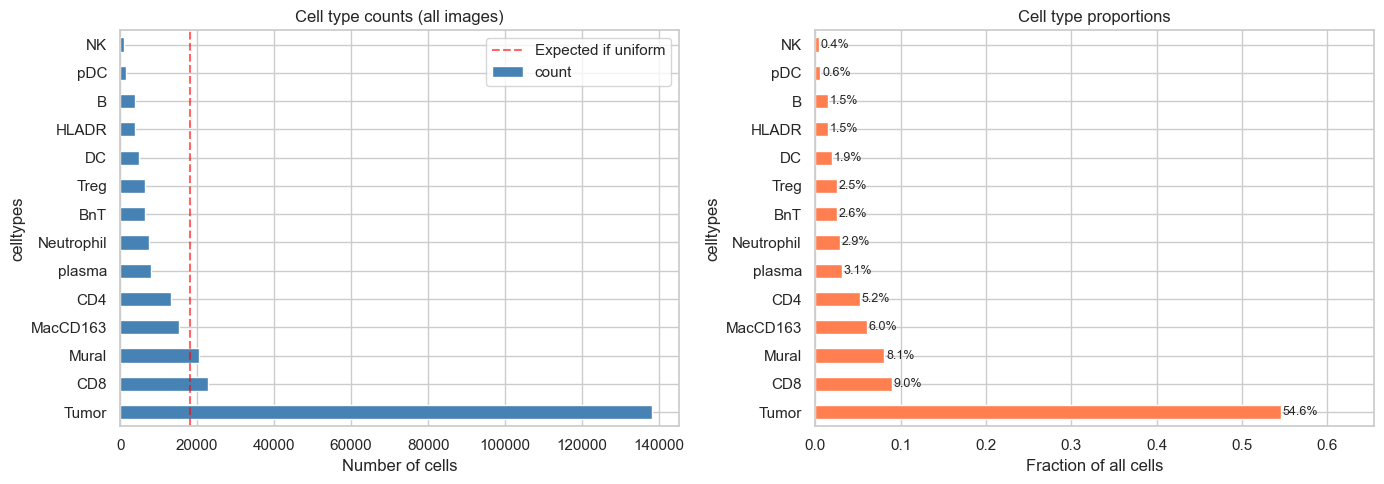

Most abundant: Tumor (54.6% of all cells)


In [6]:
celltype_counts = adata.obs['celltypes'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Counts
celltype_counts.plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_xlabel('Number of cells')
axes[0].set_title('Cell type counts (all images)')
axes[0].axvline(x=adata.n_obs / adata.obs['celltypes'].nunique(), color='red',
                linestyle='--', alpha=0.6, label='Expected if uniform')
axes[0].legend()

# Proportions
proportions = celltype_counts / celltype_counts.sum()
proportions.plot(kind='barh', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_xlabel('Fraction of all cells')
axes[1].set_title('Cell type proportions')
axes[1].set_xlim(0, proportions.max() * 1.2)
for i, v in enumerate(proportions):
    axes[1].text(v + 0.002, i, f'{v:.1%}', va='center', fontsize=9)

plt.tight_layout()
plt.show()
print(f"Most abundant: {celltype_counts.index[0]} ({proportions.iloc[0]:.1%} of all cells)")

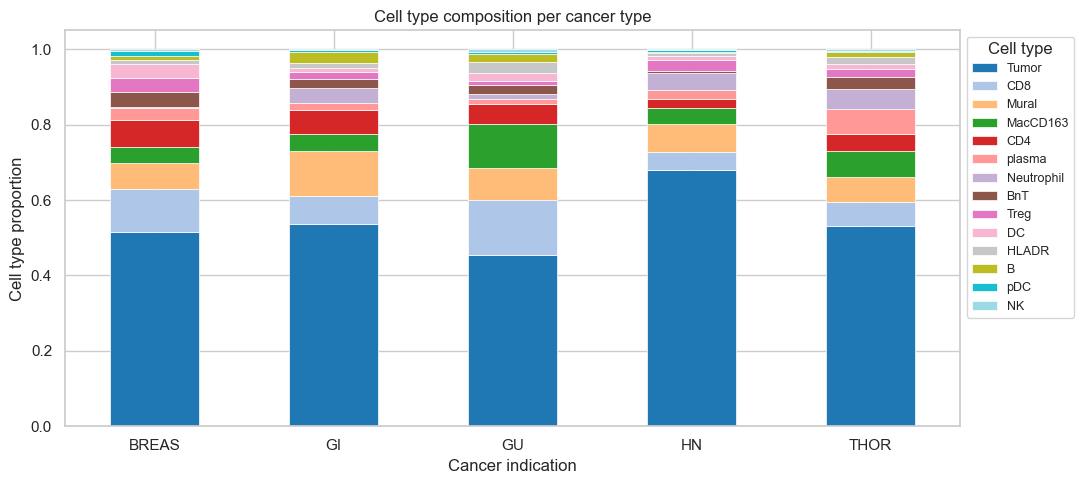

Tumor proportion per indication:
Indication
HN       67.9%
GI       53.6%
THOR     53.2%
BREAS    51.6%
GU       45.6%
Name: Tumor, dtype: object


In [ ]:
# ── Cell type composition broken down by cancer indication ────────────────────
# This reveals whether different cancer types have different immune environments
# BREAS — Breast cancer
# GI — Gastrointestinal cancers
# GU — Genitourinary cancers
# HN — Head and neck cancers
# THOR — Thoracic cancers

indication_celltype = (
    adata.obs.groupby(['Indication', 'celltypes'], observed=True)
    .size()
    .unstack(fill_value=0)
)
# Normalise to proportions within each indication
indication_celltype_prop = indication_celltype.div(indication_celltype.sum(axis=1), axis=0)

# Order cell types by overall abundance
order = celltype_counts.index.tolist()
indication_celltype_prop = indication_celltype_prop[order]

ax = indication_celltype_prop.plot(
    kind='bar', stacked=True, figsize=(11, 5),
    colormap='tab20', edgecolor='white', linewidth=0.5
)
ax.set_xlabel('Cancer indication')
ax.set_ylabel('Cell type proportion')
ax.set_title('Cell type composition per cancer type')
ax.legend(loc='upper left', bbox_to_anchor=(1, 1), title='Cell type', fontsize=9)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

print("Tumor proportion per indication:")
print(indication_celltype_prop['Tumor'].sort_values(ascending=False).apply(lambda x: f'{x:.1%}'))

### 🎯 Exercise 1.1

**Question:** Which cancer indication has the highest proportion of CD8+ T cells?  
**Follow-up:** Is this consistent with immunological expectations for these cancer types?

In [8]:
# Your code here
cd8_by_indication = indication_celltype_prop['CD8'].sort_values(ascending=False)
print("CD8+ T cell proportion by cancer type:")
print(cd8_by_indication.apply(lambda x: f'{x:.2%}'))

CD8+ T cell proportion by cancer type:
Indication
GU       14.48%
BREAS    11.29%
GI        7.64%
THOR      6.34%
HN        4.84%
Name: CD8, dtype: object


---
## Part 3: Protein Expression Analysis

### Why arcsinh transformation?

IMC/CyTOF data are **ion counts** — highly right-skewed with many near-zero values and occasional extreme outliers. The arcsinh with cofactor 5 maps:
- Low counts (0–5) → near-linearly
- High counts (>5) → logarithmically

$$x_{\text{transformed}} = \sinh^{-1}\!\left(\frac{x}{5}\right)$$

This compresses the dynamic range and stabilises variance so that downstream statistics (means, correlations) are interpretable.

In [9]:
# Create arcsinh layer (cofactor = 5, standard for IMC/CyTOF)
if 'exprs_arcsinh' not in adata.layers:
    adata.layers['exprs_arcsinh'] = np.arcsinh(adata.layers['exprs'] / 5)
    print("Created 'exprs_arcsinh' layer")
else:
    print("'exprs_arcsinh' already exists")

# Show the transformation on a few values
test_vals = np.array([0, 1, 5, 10, 50, 100, 500])
print(f"\n{'Raw':>6}  {'arcsinh(x/5)':>14}")
for v in test_vals:
    print(f"{v:>6}  {np.arcsinh(v/5):>14.3f}")

Created 'exprs_arcsinh' layer

   Raw    arcsinh(x/5)
     0           0.000
     1           0.199
     5           0.881
    10           1.444
    50           2.998
   100           3.690
   500           5.298


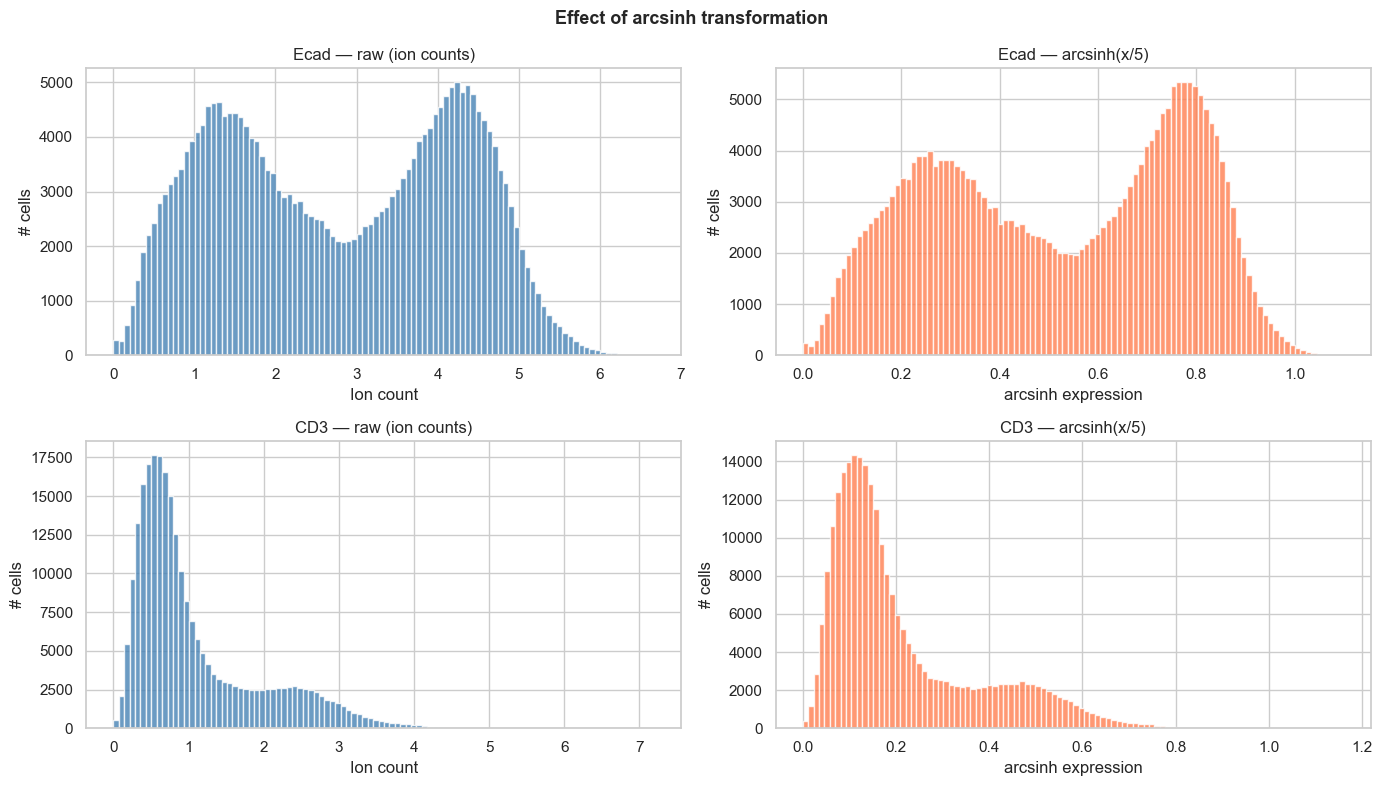

In [10]:
# Visualise raw vs transformed for two markers: Ecad (Tumor marker) and CD3 (T cell marker)
markers_to_show = ['Ecad', 'CD3']

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for row, mname in enumerate(markers_to_show):
    midx = np.where(adata.var['marker'] == mname)[0][0]
    raw = adata.layers['exprs'][:, midx]
    transformed = adata.layers['exprs_arcsinh'][:, midx]

    axes[row, 0].hist(raw, bins=100, color='steelblue', alpha=0.8)
    axes[row, 0].set_title(f'{mname} — raw (ion counts)')
    axes[row, 0].set_xlabel('Ion count')
    axes[row, 0].set_ylabel('# cells')

    axes[row, 1].hist(transformed, bins=100, color='coral', alpha=0.8)
    axes[row, 1].set_title(f'{mname} — arcsinh(x/5)')
    axes[row, 1].set_xlabel('arcsinh expression')
    axes[row, 1].set_ylabel('# cells')

plt.suptitle('Effect of arcsinh transformation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

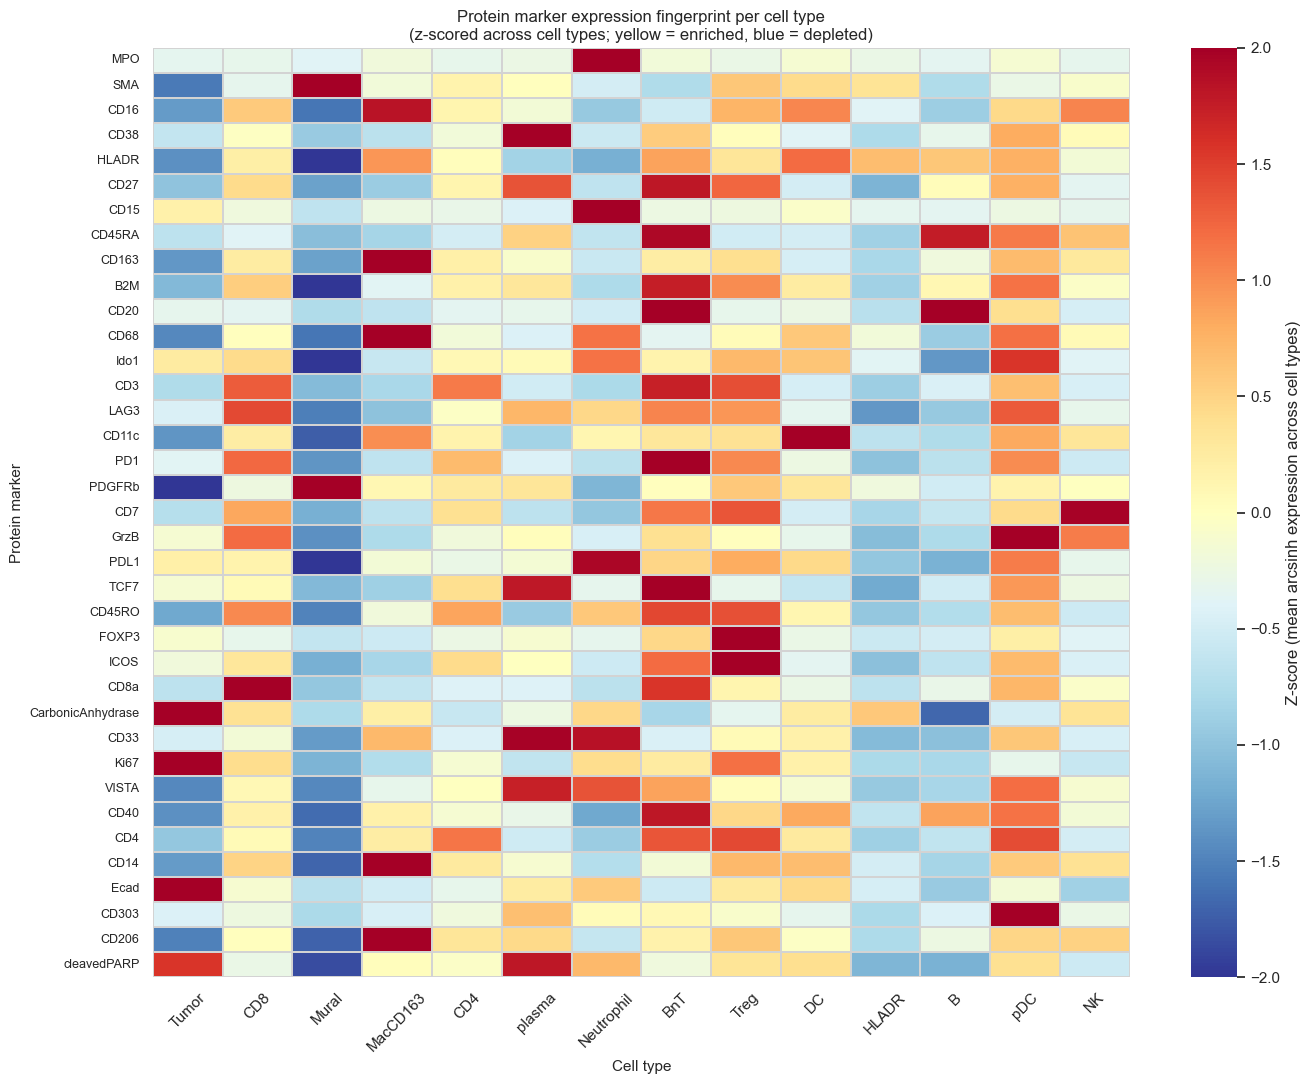

Key expected patterns:
  Ecad      → Tumor (epithelial marker)
  CD3/CD8a  → CD8 T cells
  CD3/CD4   → CD4 T cells
  CD163/CD68→ Macrophages (MacCD163)
  FOXP3     → Tregs (regulatory T cells)
  CD20      → B cells
  SMA       → Mural cells (pericytes/smooth muscle)


In [11]:
# ── Mean marker expression per cell type — the core fingerprint plot ──────────
#
# This heatmap shows WHAT makes each cell type unique: each column is a
# cell type, each row is a marker. The colour encodes mean arcsinh expression.
# High values (yellow) = defining marker; low values (dark) = absent.

# Use only the 37 analysed markers (use_channel == 1)
use_markers = adata.var['use_channel'] == 1
marker_names = adata.var.loc[use_markers, 'marker'].values

# Build matrix: cell_types × markers
expr_matrix = adata.layers['exprs_arcsinh'][:, use_markers]
cell_types_order = celltype_counts.index.tolist()   # sorted by abundance

mean_expr = pd.DataFrame(
    index=marker_names,
    columns=cell_types_order,
    dtype=float
)
for ct in cell_types_order:
    mask = adata.obs['celltypes'] == ct
    mean_expr[ct] = expr_matrix[mask].mean(axis=0)

# Z-score across cell types for each marker (highlights relative enrichment)
mean_expr_z = mean_expr.sub(mean_expr.mean(axis=1), axis=0).div(mean_expr.std(axis=1) + 1e-6, axis=0)

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(
    mean_expr_z,
    cmap='RdYlBu_r',
    center=0, vmin=-2, vmax=2,
    linewidths=0.3, linecolor='lightgrey',
    ax=ax,
    cbar_kws={'label': 'Z-score (mean arcsinh expression across cell types)'}
)
ax.set_title('Protein marker expression fingerprint per cell type\n'
             '(z-scored across cell types; yellow = enriched, blue = depleted)',
             fontsize=12)
ax.set_xlabel('Cell type', fontsize=11)
ax.set_ylabel('Protein marker', fontsize=11)
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', labelsize=9)
plt.tight_layout()
plt.show()

print("Key expected patterns:")
print("  Ecad      → Tumor (epithelial marker)")
print("  CD3/CD8a  → CD8 T cells")
print("  CD3/CD4   → CD4 T cells")
print("  CD163/CD68→ Macrophages (MacCD163)")
print("  FOXP3     → Tregs (regulatory T cells)")
print("  CD20      → B cells")
print("  SMA       → Mural cells (pericytes/smooth muscle)")

/var/folders/24/9ggqzqs92qdc3b845dk3z2b00000gn/T/ipykernel_22042/1804012146.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  order = (plot_df.groupby('celltype')['expression']
/var/folders/24/9ggqzqs92qdc3b845dk3z2b00000gn/T/ipykernel_22042/1804012146.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, y='celltype', x='expression',
/var/folders/24/9ggqzqs92qdc3b845dk3z2b00000gn/T/ipykernel_22042/1804012146.py:15: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(data=plot_df, y='celltype', x='expression',
/var/folders/24/9ggq

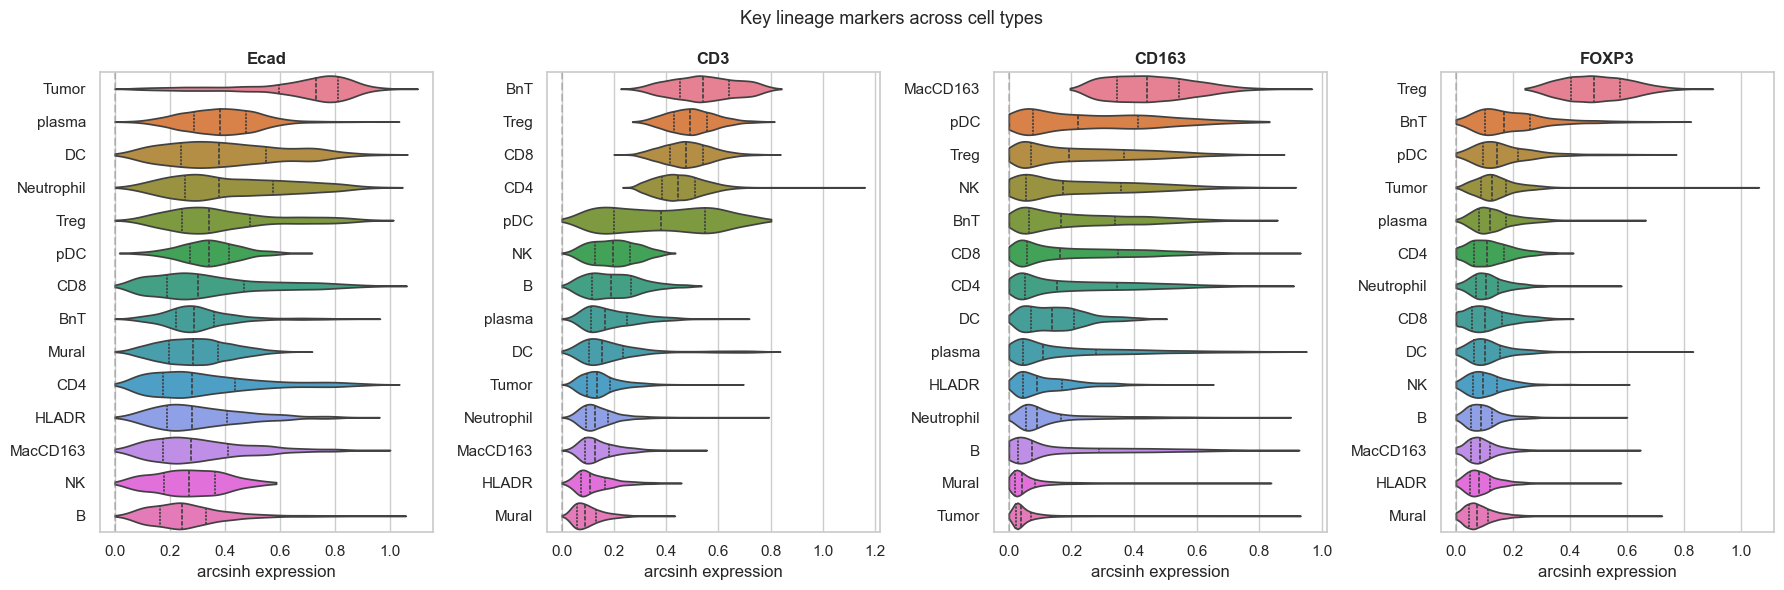

In [12]:
# ── Violin plots for key lineage markers ──────────────────────────────────────
# Select 4 lineage-defining markers and show expression across all cell types

key_markers = ['Ecad', 'CD3', 'CD163', 'FOXP3']
fig, axes = plt.subplots(1, 4, figsize=(18, 6))

for ax, mname in zip(axes, key_markers):
    midx = np.where(adata.var['marker'] == mname)[0][0]
    expr_vals = adata.layers['exprs_arcsinh'][:, midx]
    plot_df = pd.DataFrame({'expression': expr_vals,
                            'celltype': adata.obs['celltypes'].values})
    # Order cell types by median expression of this marker
    order = (plot_df.groupby('celltype')['expression']
             .median().sort_values(ascending=False).index)
    sns.violinplot(data=plot_df, y='celltype', x='expression',
                   order=order, orient='h', ax=ax,
                   palette='husl', inner='quartile', cut=0, scale='width')
    ax.set_title(f'{mname}', fontsize=12, fontweight='bold')
    ax.set_xlabel('arcsinh expression')
    ax.set_ylabel('')
    ax.axvline(x=0, color='grey', linestyle='--', alpha=0.4)

plt.suptitle('Key lineage markers across cell types', fontsize=13)
plt.tight_layout()
plt.show()

### 🎯 Exercise 1.2

**Task:** Pick any marker from the panel that you expect to be a **checkpoint / exhaustion marker** and plot its expression across cell types. Which cell type expresses it most?

*Hint:* Candidates include `PD1`, `LAG3`, `ICOS`, `GrzB`, `PDL1`.

/var/folders/24/9ggqzqs92qdc3b845dk3z2b00000gn/T/ipykernel_22042/977312823.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  order = plot_df.groupby('celltype')['expression'].median().sort_values(ascending=False).index
/var/folders/24/9ggqzqs92qdc3b845dk3z2b00000gn/T/ipykernel_22042/977312823.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, y='celltype', x='expression',
/var/folders/24/9ggqzqs92qdc3b845dk3z2b00000gn/T/ipykernel_22042/977312823.py:11: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(data=plot_df, y='celltype

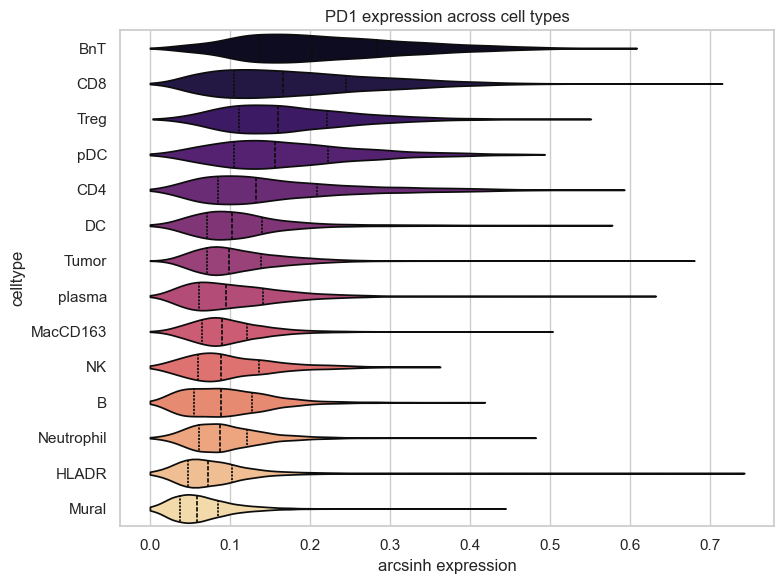

Highest median PD1: BnT


/var/folders/24/9ggqzqs92qdc3b845dk3z2b00000gn/T/ipykernel_22042/977312823.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  top_ct = plot_df.groupby('celltype')['expression'].median().idxmax()


In [13]:
# Your code here
marker_of_interest = 'PD1'
midx = np.where(adata.var['marker'] == marker_of_interest)[0][0]
expr_vals = adata.layers['exprs_arcsinh'][:, midx]

plot_df = pd.DataFrame({'expression': expr_vals,
                        'celltype': adata.obs['celltypes'].values})
order = plot_df.groupby('celltype')['expression'].median().sort_values(ascending=False).index

plt.figure(figsize=(8, 6))
sns.violinplot(data=plot_df, y='celltype', x='expression',
               order=order, orient='h', palette='magma', inner='quartile',
               cut=0, scale='width')
plt.title(f'{marker_of_interest} expression across cell types')
plt.xlabel('arcsinh expression')
plt.tight_layout()
plt.show()

top_ct = plot_df.groupby('celltype')['expression'].median().idxmax()
print(f"Highest median {marker_of_interest}: {top_ct}")

---
## Part 4: Image-Level Compositional Analysis

Each tissue image has a unique **cellular composition** (the fraction of each cell type).  
Compositional analysis treats images as vectors in the simplex $\Delta^{K-1}$ (proportions summing to 1).

Key insight: tumours with more CD8+ T cells (immune-hot) have different biology and often better prognosis than immune-cold tumours.

In [14]:
# ── Build image × cell_type count/proportion matrices ─────────────────────────
image_ct_counts = pd.pivot_table(
    adata.obs, index='image', columns='celltypes',
    aggfunc='size', fill_value=0
)
# Flatten index/columns (pivot_table may return CategoricalIndex in newer pandas)
image_ct_counts.columns = image_ct_counts.columns.tolist()
image_ct_counts.index = image_ct_counts.index.tolist()
image_ct_props = image_ct_counts.div(image_ct_counts.sum(axis=1), axis=0)

print(f"Matrix shape: {image_ct_props.shape}  (images × cell types)")
print(f"Row sums (should all be 1): range [{image_ct_props.sum(axis=1).min():.4f}, "
      f"{image_ct_props.sum(axis=1).max():.4f}]")
print()
print("Average composition across all images:")
avg = image_ct_props.mean(axis=0).sort_values(ascending=False)
for ct, val in avg.items():
    print(f"  {ct:<15} {val:.2%}")

Matrix shape: (132, 14)  (images × cell types)
Row sums (should all be 1): range [1.0000, 1.0000]

Average composition across all images:
  Tumor           50.14%
  Mural           10.88%
  CD8             8.85%
  MacCD163        6.98%
  CD4             5.51%
  plasma          3.07%
  Neutrophil      3.04%
  Treg            2.50%
  BnT             2.20%
  DC              2.19%
  HLADR           2.14%
  B               1.43%
  pDC             0.58%
  NK              0.49%


/var/folders/24/9ggqzqs92qdc3b845dk3z2b00000gn/T/ipykernel_22042/307523459.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  image_ct_counts = pd.pivot_table(


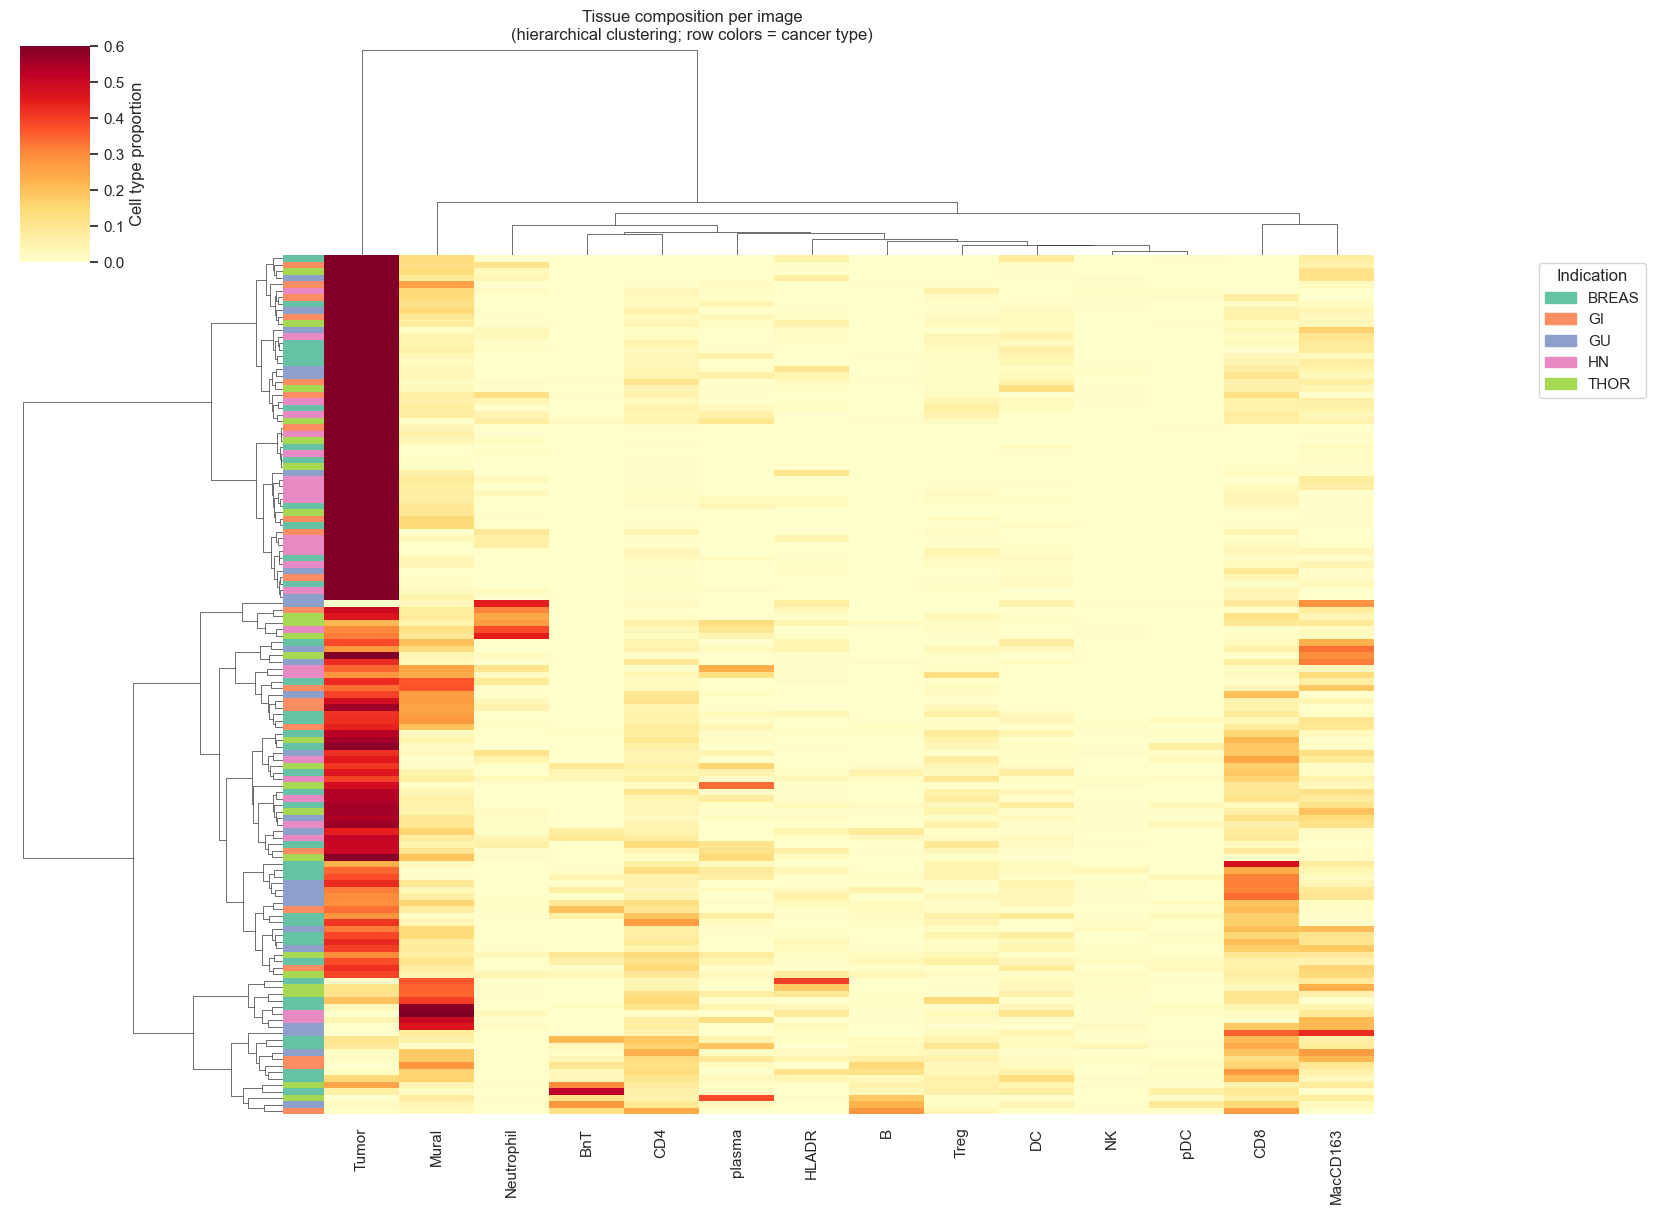

In [15]:
# ── Clustermap: images × cell types ───────────────────────────────────────────
# Hierarchical clustering groups images with similar composition
# and groups cell types that co-vary across images

# Add indication as row color
indication_map = adata.obs.groupby('image', observed=True)['Indication'].first()
# Ensure index is plain strings
indication_map.index = indication_map.index.tolist()

indication_palette = dict(zip(
    sorted(adata.obs['Indication'].unique()),
    sns.color_palette('Set2', adata.obs['Indication'].nunique())
))

# Build row_colors as a plain Series aligned to image_ct_props index
row_colors = pd.Series(
    [indication_palette.get(indication_map.get(img, ''), (0.7, 0.7, 0.7))
     for img in image_ct_props.index],
    index=image_ct_props.index
)

g = sns.clustermap(
    image_ct_props,
    cmap='YlOrRd',
    vmin=0, vmax=0.6,
    figsize=(14, 12),
    row_colors=row_colors,
    xticklabels=True,
    yticklabels=False,
    method='ward',
    cbar_kws={'label': 'Cell type proportion'}
)
# Add legend for cancer type
from matplotlib.patches import Patch
handles = [Patch(color=c, label=l) for l, c in indication_palette.items()]
g.ax_heatmap.legend(handles=handles, title='Indication',
                    loc='upper left', bbox_to_anchor=(1.15, 1))
g.fig.suptitle('Tissue composition per image\n'
               '(hierarchical clustering; row colors = cancer type)',
               y=1.01, fontsize=12)
plt.show()

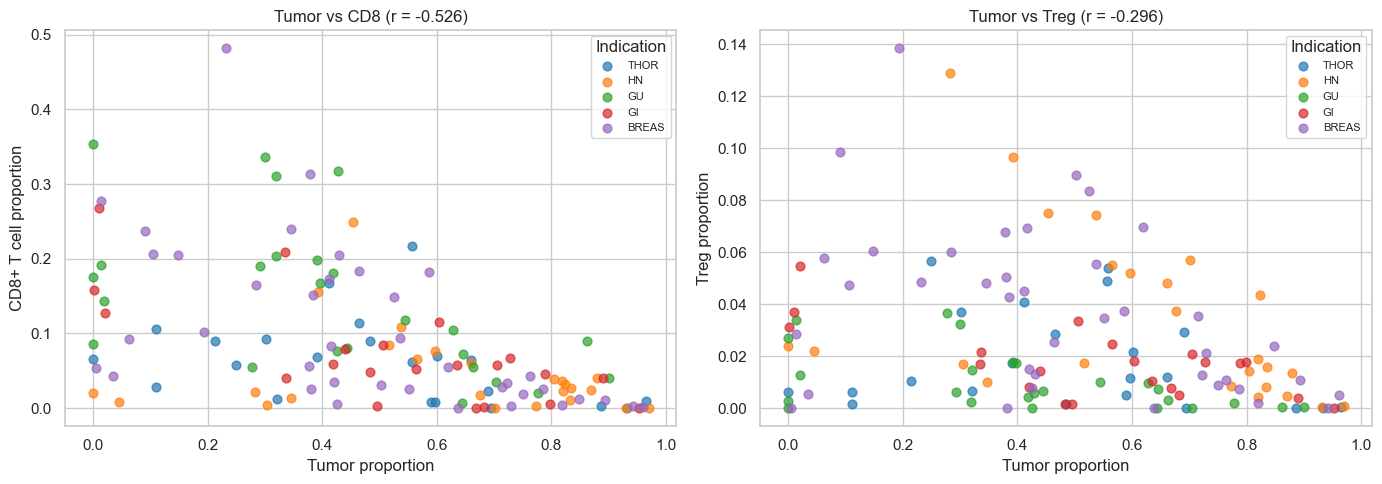

Interpretation:
  r(Tumor, CD8) > 0  → CD8 T cells found where tumor is present (immune-hot)
  r(Tumor, Treg) > 0 → Tregs accompany tumor (immunosuppression)


In [16]:
# ── Scatter plots: pairwise relationships between cell type proportions ────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Tumor vs CD8 — key prognostic axis
for ind in adata.obs['Indication'].unique():
    imgs = indication_map[indication_map == ind].index
    imgs = [i for i in imgs if i in image_ct_props.index]
    axes[0].scatter(
        image_ct_props.loc[imgs, 'Tumor'],
        image_ct_props.loc[imgs, 'CD8'],
        label=ind, alpha=0.7, s=40
    )
r01 = image_ct_props[['Tumor', 'CD8']].corr().iloc[0, 1]
axes[0].set_xlabel('Tumor proportion')
axes[0].set_ylabel('CD8+ T cell proportion')
axes[0].set_title(f'Tumor vs CD8 (r = {r01:.3f})')
axes[0].legend(title='Indication', fontsize=8)

# Right: Tumor vs Treg — immunosuppressive axis
for ind in adata.obs['Indication'].unique():
    imgs = indication_map[indication_map == ind].index
    imgs = [i for i in imgs if i in image_ct_props.index]
    axes[1].scatter(
        image_ct_props.loc[imgs, 'Tumor'],
        image_ct_props.loc[imgs, 'Treg'],
        label=ind, alpha=0.7, s=40
    )
r02 = image_ct_props[['Tumor', 'Treg']].corr().iloc[0, 1]
axes[1].set_xlabel('Tumor proportion')
axes[1].set_ylabel('Treg proportion')
axes[1].set_title(f'Tumor vs Treg (r = {r02:.3f})')
axes[1].legend(title='Indication', fontsize=8)

plt.tight_layout()
plt.show()

print("Interpretation:")
print("  r(Tumor, CD8) > 0  → CD8 T cells found where tumor is present (immune-hot)")
print("  r(Tumor, Treg) > 0 → Tregs accompany tumor (immunosuppression)")

### 🎯 Exercise 1.3

**Task:** Find the **5 images** with the highest CD8+ T cell proportion. What cancer indications do they belong to?

**Follow-up:** Compute the correlation between CD8 and Treg proportions. Is it positive or negative? What does this imply biologically?

In [17]:
# Your code here
top5_cd8 = image_ct_props['CD8'].nlargest(5)
print("Top 5 images by CD8 proportion:")
for img, val in top5_cd8.items():
    ind = indication_map.get(img, 'unknown')
    print(f"  {img[-50:]:50s}  CD8={val:.2%}  [{ind}]")

r_cd8_treg = image_ct_props[['CD8', 'Treg']].corr().iloc[0, 1]
print(f"\nCorrelation CD8 vs Treg: r = {r_cd8_treg:.3f}")

Top 5 images by CD8 proportion:
  20210701_10067447-SPECT-VAR-TIS-01-IMC-01_003.tiff  CD8=48.18%  [BREAS]
  tch20210506_10032400-GU-VAR-TIS-01-IMC-01_003.tiff  CD8=35.43%  [GU]
  tch20200528_10042698-GU-VAR-TIS-01-IMC-01_002.tiff  CD8=33.61%  [GU]
  tch20200528_10037092-GU-VAR-TIS-01-IMC-01_001.tiff  CD8=31.72%  [GU]
  IMMUcan_Batch20220609_S-220218-00008_003.tiff       CD8=31.39%  [BREAS]

Correlation CD8 vs Treg: r = 0.296


---
## Part 5: PCA of Image Compositions

### Why Hellinger transformation before PCA?

Proportions are **compositional** data — they are constrained (sum to 1), so ordinary Euclidean distances are distorted.  
The **Hellinger transformation** $h_k = \sqrt{p_k}$ partially solves this by:
1. Compressing large proportions
2. Making the Euclidean distance in Hellinger space equivalent to the chi-squared distance in proportion space
3. Preventing dominant cell types from overwhelming the PCA

In [18]:
# Hellinger transform and PCA
image_ct_hell = np.sqrt(image_ct_props)

n_comp = 8
pca = PCA(n_components=n_comp)
pca_embed = pca.fit_transform(image_ct_hell)

print("Explained variance per component:")
for i, ev in enumerate(pca.explained_variance_ratio_):
    bar = '█' * int(ev * 100)
    print(f"  PC{i+1}: {ev:.2%}  {bar}")
print(f"  Total ({n_comp} PCs): {pca.explained_variance_ratio_.sum():.2%}")

Explained variance per component:
  PC1: 41.71%  █████████████████████████████████████████
  PC2: 16.01%  ████████████████
  PC3: 9.22%  █████████
  PC4: 8.31%  ████████
  PC5: 5.60%  █████
  PC6: 5.50%  █████
  PC7: 3.70%  ███
  PC8: 2.84%  ██
  Total (8 PCs): 92.89%


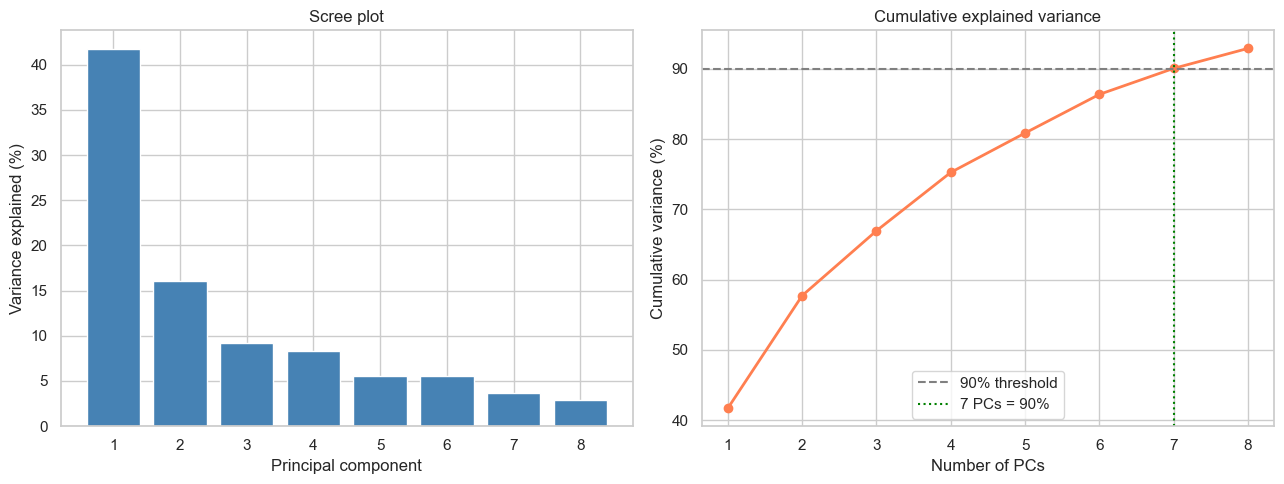

PCs needed for ≥90% variance: 7


In [19]:
# Scree plot
cumvar = np.cumsum(pca.explained_variance_ratio_)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(range(1, n_comp+1), pca.explained_variance_ratio_ * 100,
            color='steelblue', edgecolor='white')
axes[0].set_xlabel('Principal component')
axes[0].set_ylabel('Variance explained (%)')
axes[0].set_title('Scree plot')
axes[0].set_xticks(range(1, n_comp+1))

axes[1].plot(range(1, n_comp+1), cumvar * 100, 'o-', color='coral', linewidth=2)
axes[1].axhline(y=90, color='grey', linestyle='--', label='90% threshold')
n_for_90 = int(np.argmax(cumvar >= 0.90)) + 1
axes[1].axvline(x=n_for_90, color='green', linestyle=':', label=f'{n_for_90} PCs = 90%')
axes[1].set_xlabel('Number of PCs')
axes[1].set_ylabel('Cumulative variance (%)')
axes[1].set_title('Cumulative explained variance')
axes[1].legend()
axes[1].set_xticks(range(1, n_comp+1))

plt.tight_layout()
plt.show()
print(f"PCs needed for ≥90% variance: {n_for_90}")

/var/folders/24/9ggqzqs92qdc3b845dk3z2b00000gn/T/ipykernel_22042/2760094683.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for ind, grp in pca_df.groupby('Indication'):


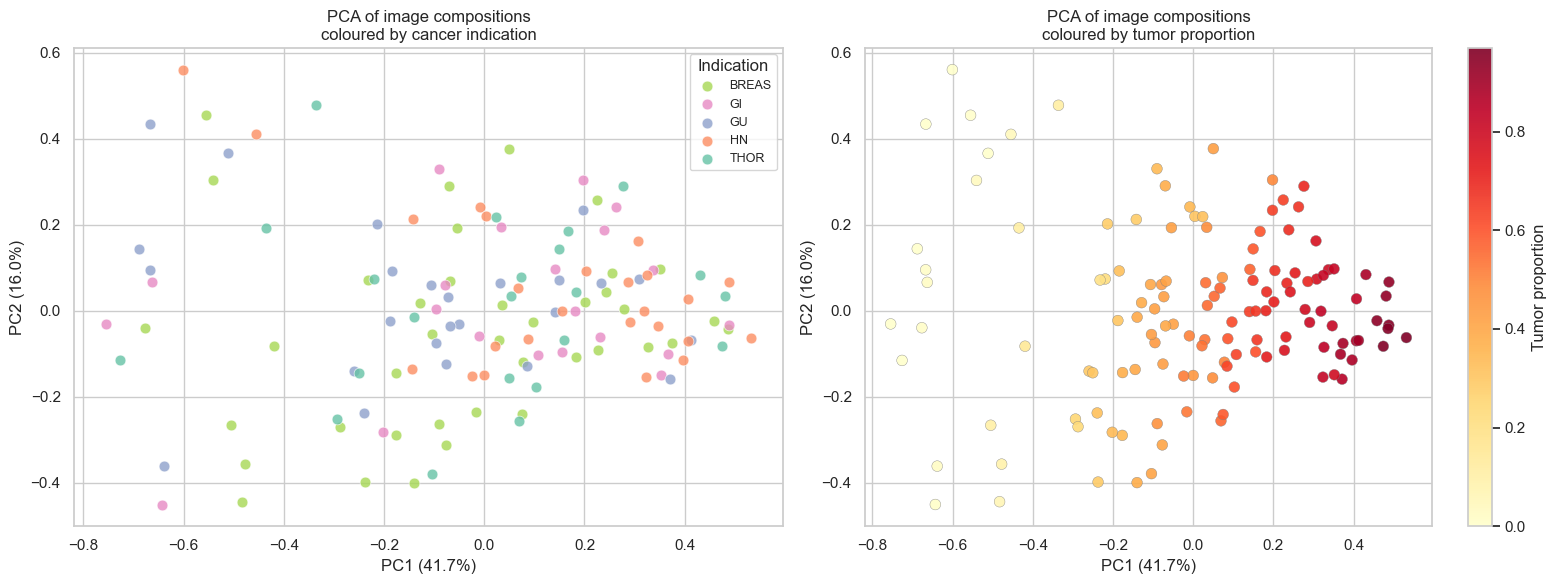

In [20]:
# ── PCA scatter colored by cancer indication ───────────────────────────────────
pca_df = pd.DataFrame(pca_embed[:, :4],
                      columns=[f'PC{i+1}' for i in range(4)],
                      index=image_ct_props.index)
pca_df['Indication'] = pca_df.index.map(indication_map)
pca_df['TumorProp'] = image_ct_props['Tumor'].values

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: colored by indication
palette = dict(zip(adata.obs['Indication'].unique(),
                   sns.color_palette('Set2', adata.obs['Indication'].nunique())))
for ind, grp in pca_df.groupby('Indication'):
    axes[0].scatter(grp['PC1'], grp['PC2'], label=ind,
                    color=palette[ind], alpha=0.8, s=60, edgecolors='white', linewidth=0.5)
axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
axes[0].set_title('PCA of image compositions\ncoloured by cancer indication')
axes[0].legend(title='Indication', fontsize=9)

# Right: colored by tumor proportion (continuous)
sc = axes[1].scatter(pca_df['PC1'], pca_df['PC2'],
                     c=pca_df['TumorProp'], cmap='YlOrRd', s=60,
                     edgecolors='grey', linewidth=0.3, alpha=0.9)
plt.colorbar(sc, ax=axes[1], label='Tumor proportion')
axes[1].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
axes[1].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
axes[1].set_title('PCA of image compositions\ncoloured by tumor proportion')

plt.tight_layout()
plt.show()

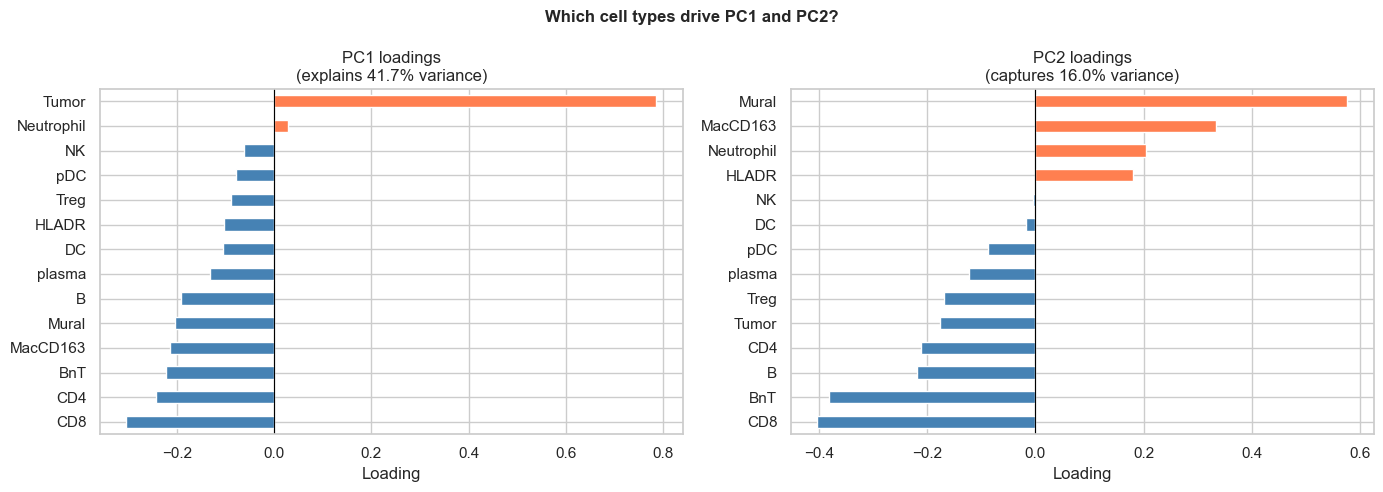

PC1: positive = cell types that increase together on one axis
     negative = cell types that increase on the opposite axis

PC1 positive pole: ['Tumor', 'Neutrophil', 'NK']
PC1 negative pole: ['CD8', 'CD4', 'BnT']


In [21]:
# ── PC1 and PC2 loadings: which cell types drive each axis? ───────────────────
loadings = pd.DataFrame(
    pca.components_[:2].T,
    index=image_ct_props.columns,
    columns=['PC1', 'PC2']
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, pc in zip(axes, ['PC1', 'PC2']):
    sorted_load = loadings[pc].sort_values()
    colors = ['coral' if v > 0 else 'steelblue' for v in sorted_load]
    sorted_load.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
    ax.axvline(x=0, color='black', linewidth=0.8)
    ax.set_title(f'{pc} loadings\n({"explains" if pc=="PC1" else "captures"} '
                 f'{pca.explained_variance_ratio_[["PC1","PC2"].index(pc)]:.1%} variance)')
    ax.set_xlabel('Loading')

plt.suptitle('Which cell types drive PC1 and PC2?', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("PC1: positive = cell types that increase together on one axis")
print("     negative = cell types that increase on the opposite axis")
print(f"\nPC1 positive pole: {loadings['PC1'].nlargest(3).index.tolist()}")
print(f"PC1 negative pole: {loadings['PC1'].nsmallest(3).index.tolist()}")

### 🎯 Exercise 1.4

**Task:** Redo the PCA analysis **without** the Hellinger transformation (use raw proportions). Compare the scree plot and loadings. Does PC1 still have the same biological interpretation?

*Hint:* The Tumor cell type has by far the highest proportions. What happens to its loading in raw-proportion PCA?

In [22]:
# Your code here — compare Hellinger PCA vs raw proportion PCA
pca_raw = PCA(n_components=4)
embed_raw = pca_raw.fit_transform(image_ct_props)

loadings_raw = pd.DataFrame(
    pca_raw.components_[:2].T,
    index=image_ct_props.columns,
    columns=['PC1_raw', 'PC2_raw']
)

comparison = loadings[['PC1']].join(loadings_raw[['PC1_raw']])
print("PC1 loadings — Hellinger vs raw proportions:")
print(comparison.sort_values('PC1').to_string())
print()
print(f"Hellinger PC1 variance: {pca.explained_variance_ratio_[0]:.2%}")
print(f"Raw prop  PC1 variance: {pca_raw.explained_variance_ratio_[0]:.2%}")

PC1 loadings — Hellinger vs raw proportions:
                 PC1   PC1_raw
CD8        -0.304061 -0.166524
CD4        -0.243401 -0.109211
BnT        -0.222613 -0.080882
MacCD163   -0.213572 -0.122565
Mural      -0.203732 -0.202423
B          -0.191655 -0.058536
plasma     -0.131261 -0.055995
DC         -0.103974 -0.025825
HLADR      -0.102411 -0.044334
Treg       -0.088279 -0.026792
pDC        -0.077776 -0.011935
NK         -0.062592 -0.008752
Neutrophil  0.028673 -0.027973
Tumor       0.785993  0.941748

Hellinger PC1 variance: 41.71%
Raw prop  PC1 variance: 67.48%


---
## Summary

| Concept | Key takeaway |
|---|---|
| AnnData | Unified container: `.obs` (cells), `.var` (markers), `.layers` (expression matrices) |
| Arcsinh(x/5) | Compresses ion count skewness; cofactor 5 is standard for IMC/CyTOF |
| Marker fingerprint heatmap | Z-scored mean expression shows what defines each cell type |
| Image composition | Each image is a proportion vector; tumours vary dramatically |
| Hellinger PCA | Removes dominance of high-proportion cell types; reveals biologically meaningful axes |

**Next:** Tutorial 2 will visualise *where* cells are in tissue space — turning expression + coordinates into spatial maps.

---